# Artificial Intelligence and Application Midterm Exam

Konrad Wojda, 9307820244

## Task 1

To load and process data I will use pandas library and for drawing graph I will use pyplot from matplotlib.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

Firstly, let's load data and convert datetime strings to datetime.

In [61]:
data_frame = pd.read_csv('data/2024-03-transaction.csv')

data_frame['timestamp'] = pd.to_datetime(data_frame['timestamp'])

Next, let's filter data by extracting hour from each timestamp.

In [62]:
data_frame['hour'] = data_frame['timestamp'].dt.floor('h')

Finally, use groupby on hour and side to aggregate number of transactions during each hour.

In [63]:
transaction_counts = data_frame.groupby(['hour', 'side']).size().unstack(fill_value=0)
transaction_counts.columns = ['buy', 'sell']

Now, let's create plot with output data.

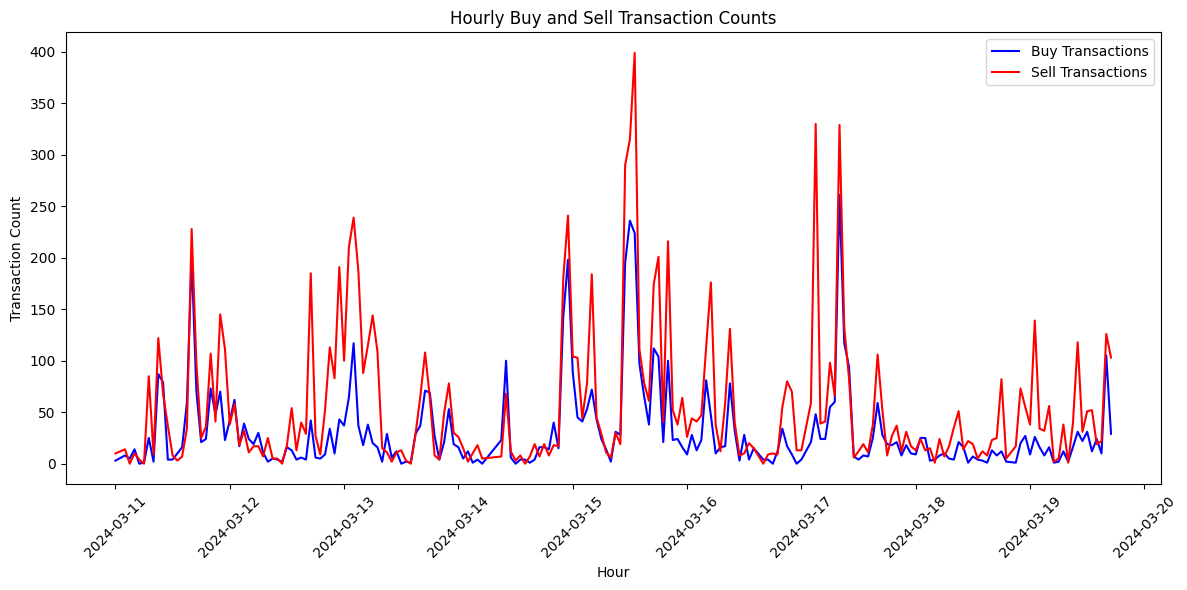

In [64]:
plt.figure(figsize=(12, 6))
plt.plot(transaction_counts.index, transaction_counts['buy'], label='Buy Transactions', color='blue')
plt.plot(transaction_counts.index, transaction_counts['sell'], label='Sell Transactions', color='red')

plt.xlabel('Hour')
plt.ylabel('Transaction Count')
plt.title('Hourly Buy and Sell Transaction Counts')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Task 2

Firstly, data loading:

In [65]:
transactions = pd.read_csv('data/2024-03-11-transaction.csv')
raw_data = pd.read_csv('data/2024-03-11-rawdata.csv')

Secondly, let's parse datatime strings and remove us from raw_data timestamps.

In [66]:
transactions['timestamp'] = pd.to_datetime(transactions['timestamp'], format='%Y-%m-%d %H:%M')
raw_data['timestamp'] = pd.to_datetime(raw_data['timestamp'], format='%Y-%m-%d %H:%M:%S.%f').dt.floor('s')

Next, I will remove all raw_data records, that has second part of timestamp set to other value than `0`. This is because transactions file has timestamps only in full minutes (which implies second set to `0`).

In [67]:
raw_data = raw_data[raw_data['timestamp'].dt.second == 0]

Next, let's use `groupby` to group raw_data by timestamp.

In [68]:
grouped_raw_data = raw_data.groupby('timestamp')

Now, I can define function that will calulate new features based on single group. 

In [69]:
def calculate_features(orderbook_slice):
    top_bid_price = orderbook_slice[orderbook_slice['type'] == 0]['price'].iloc[0]
    top_ask_price = orderbook_slice[orderbook_slice['type'] == 1]['price'].iloc[0]
    midprice = (top_ask_price + top_bid_price) * 0.5

    askQty = orderbook_slice[orderbook_slice['type'] == 1]['quantity'].max()
    bidQty = orderbook_slice[orderbook_slice['type'] == 0]['quantity'].max()
    bidPx = orderbook_slice[orderbook_slice['type'] == 0]['price'].mean()

    bookfeature = (askQty * bidPx) / bidQty
    alphaprice = bookfeature - midprice

    return pd.Series([midprice, bookfeature, alphaprice], index=['midprice', 'bookfeature', 'alphaprice'])


Finally, I will apply `calculate_features` function to each group.  
After this I can merge raw_data with transactions, using keys from left table (transactions).

In [ ]:
features = grouped_raw_data.apply(calculate_features).reset_index()

transactions = pd.merge(transactions, features, left_on='timestamp', right_on='timestamp', how='left')

transactions = transactions[['midprice', 'bookfeature', 'alphaprice', 'timestamp', 'quantity', 'price', 'side']]


The output:

In [71]:
result = pd.concat([transactions.head(10), transactions.tail(10)])
print(result)

output_file = 'data/2024-03-11-transaction-modified.csv'
transactions.to_csv(output_file, index=False)

         midprice   bookfeature    alphaprice           timestamp  quantity  \
0      97798500.0  2.628835e+07 -7.151015e+07 2024-03-11 00:07:00  0.150000   
1      97798500.0  2.628835e+07 -7.151015e+07 2024-03-11 00:07:00  0.010229   
2      97798500.0  2.628835e+07 -7.151015e+07 2024-03-11 00:07:00  0.001024   
3      97784500.0  4.044031e+07 -5.734419e+07 2024-03-11 00:11:00  0.052561   
4      97597000.0  2.048226e+08  1.072256e+08 2024-03-11 00:17:00  0.039159   
5      97597000.0  2.048226e+08  1.072256e+08 2024-03-11 00:17:00  0.070000   
6      97597000.0  2.048226e+08  1.072256e+08 2024-03-11 00:17:00  0.037624   
7      97597000.0  2.048226e+08  1.072256e+08 2024-03-11 00:17:00  0.002864   
8      97597000.0  2.048226e+08  1.072256e+08 2024-03-11 00:17:00  0.001092   
9      97849000.0  1.374677e+07 -8.410223e+07 2024-03-11 00:34:00  0.001248   
2037  101286000.0  1.052174e+09  9.508882e+08 2024-03-11 23:31:00  0.004640   
2038  101286000.0  1.052174e+09  9.508882e+08 2024-0

## Task 3

To create a smart trading agent I can use `side` as a target feature, since we are operating on historical transactions data. This target will train the model to predict whether the agent should buy or sell based on the features derived from Task 2.

Firstly, import necessary libraries and load data.

In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import seaborn as sns

data_frame = pd.read_csv('data/2024-03-11-transaction-modified.csv')

Next, let's choose features and target.

In [73]:
X = data_frame[['midprice', 'bookfeature', 'alphaprice']]
X = StandardScaler().fit_transform(X)
Y = data_frame['side']

Next, we can use `train_test_split` to split data into training and testing datasets.

In [74]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=101)

After splitting dataset, we can train the model using `RandomForestClassifier`.

In [75]:
model = RandomForestClassifier(n_estimators=700, random_state=101)
model.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=700, random_state=101)

As model is trained I can use it to make some predictions and evaluate model.


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78       259
           1       0.84      0.84      0.84       356

    accuracy                           0.82       615
   macro avg       0.81      0.81      0.81       615
weighted avg       0.82      0.82      0.82       615



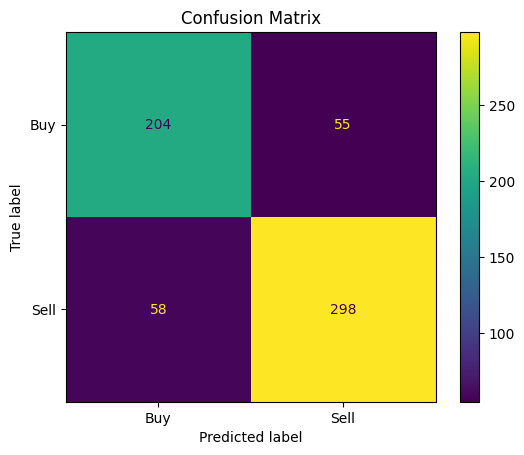

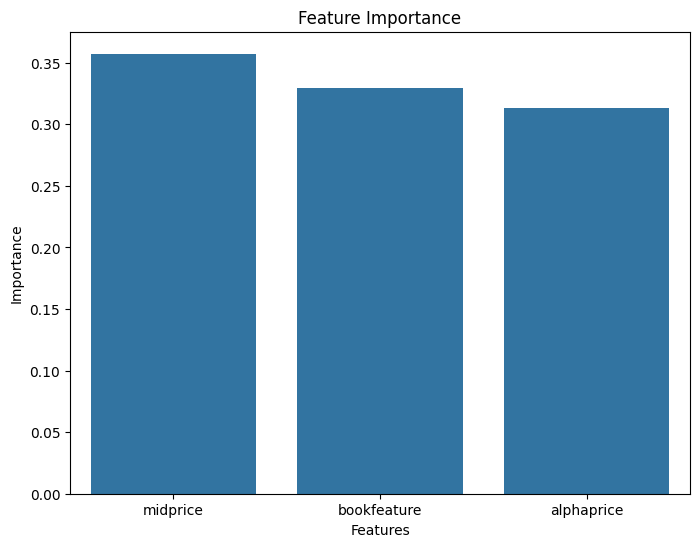

In [76]:
# Make predictions
Y_pred = model.predict(X_test)

# Evaluate the model
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, Y_test, display_labels=['Buy', 'Sell'])
plt.title("Confusion Matrix")
plt.show()

# Feature Importance
importance = model.feature_importances_
plt.figure(figsize=(8, 6))
sns.barplot(x=['midprice', 'bookfeature', 'alphaprice'], y=importance)
plt.title('Feature Importance')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.show()

## Task 4

> T4-1: Show the output images and texts of running the program.  

Unfortunately, I was not able to run it using my GPU, but here is output using CPU:

```
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #
=================================================================
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0

 conv2d (Conv2D)             (None, 28, 28, 32)        320

 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0
 D)

 conv2d_1 (Conv2D)           (None, 14, 14, 32)        9248

 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 32)          0
 g2D)

 conv2d_transpose (Conv2DTr  (None, 14, 14, 32)        9248
 anspose)

 conv2d_transpose_1 (Conv2D  (None, 28, 28, 32)        9248
 Transpose)

 conv2d_2 (Conv2D)           (None, 28, 28, 1)         289

=================================================================
Total params: 28353 (110.75 KB)
Trainable params: 28353 (110.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/2
469/469 [==============================] - 51s 108ms/step - loss: 0.1300 - val_loss: 0.0732
Epoch 2/2
469/469 [==============================] - 46s 99ms/step - loss: 0.0716 - val_loss: 0.0695
313/313 [==============================] - 3s 10ms/step
```

![](first-1.png)

![](second-1.png)

> T4-2: How long does it take to run in your environment?  

Around 2 minutes.

> T4-3: What do you think line 50 and 51 do? Overall, what do you think this program is doing? Explain briefly in your own words (Don’t explain the code). Of course, you can search in the Internet!

Lines 50 and 51 are running preprocessing functions for both train and test datasets by normalizing pixel values (scaling them to a range between 0 and 1) and reshaping the data to add a channel dimension, making it compatible with the neural network input format.

In general, this program creates a denoising autoencoder model that learns to remove noise from images of digits by training on noisy data and aiming to reproduce cleaner versions of the original images.